# Signal Processing in Practice Laboratory
## Assignment: Graph Machine Learning
### 50-Point Graded Assignment

---

**Submission instructions:**
- Make a copy of this Colab notebook and share the link in Teams as instructed.
- Use **text cells** to answer conceptual questions. Write equations in LaTeX.
- For programming tasks, use **code cells**. Submitted code must run without errors; do **not** erase outputs.
- The assignment is worth **50 points** split across two parts.

---

### 📋 Rubric Summary

| Part | Task | Points |
|------|------|--------|
| **A – Spectral Clustering** | A1: Half-Moon Dataset | 10 |
| | A2: Karate Club Social Network | 10 |
| **B – Graph Neural Networks** | B1: Node Classification on Karate Club (GNN) | 12 |
| | B2: Node Classification on Cora (GCN) | 18 |
| **Total** | | **50** |

---



In [ ]:
# Name: Dwaipayan Haldar
# SR Number: 27128

In [ ]:
# ── Package Installation ──────────────────────────────────────────────────────
# scprep is skipped — it requires a C build that fails on newer Python runtimes.
# All visualisations use plain matplotlib instead.
!pip install -q networkx matplotlib scikit-learn

import torch
print(f"PyTorch: {torch.__version__}  |  CUDA: {torch.cuda.is_available()}")

# PyTorch Geometric — stable PyPI wheel (no source build)
!pip install -q torch_geometric

# torch-scatter / torch-sparse are optional compiled extensions.
# They are NOT required for any operation in this assignment.
# Uncomment the lines below ONLY if you are on a GPU Colab runtime and
# the torch version is supported: https://data.pyg.org/whl/
# import subprocess, sys, torch
# TORCH = torch.__version__; CUDA = "cu" + torch.version.cuda.replace(".","")
# for pkg in ["torch-scatter","torch-sparse"]:
#     subprocess.run([sys.executable,"-m","pip","install","-q",pkg,
#                     "-f",f"https://data.pyg.org/whl/torch-{TORCH}+{CUDA}.html"])

print("\n✅ All packages ready.")

PyTorch: 2.10.0+cu128  |  CUDA: True
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 50.8 MB/s eta 0:00:00

✅ All packages ready.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import torch
import torch.nn.functional as F
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.preprocessing import StandardScaler
import sklearn.datasets
%matplotlib inline

# Replacement for scprep.plot.scatter2d
def scatter2d(X, c, xlabel='x0', ylabel='x1', title=''):
    plt.figure(figsize=(6,4))
    plt.scatter(X[:,0], X[:,1], c=c, cmap='Set1', s=10)
    plt.xlabel(xlabel); plt.ylabel(ylabel)
    if title: plt.title(title)
    plt.tight_layout(); plt.show()

---
## Part A – Spectral Clustering (20 points)

### Background

**Spectral clustering** leverages the eigenstructure of a graph's Laplacian to partition data into clusters. Unlike k-means (which relies on Euclidean distance), spectral clustering captures the *connectivity* structure, making it ideal for non-convex shapes.

**Algorithm Steps:**
1. Build a similarity/adjacency matrix **W** from the data.
2. Compute the degree matrix **D** and unnormalised Laplacian **L = D − W**.
3. Find the *k* smallest eigenvectors of **L** (the Fiedler vector for *k = 2*).
4. Run k-means on the eigenvector embedding.

**Key formula – Unnormalised Graph Laplacian:**
$$\mathbf{L} = \mathbf{D} - \mathbf{W}$$

**Gaussian (RBF) similarity:**
$$W_{ij} = \exp\!\left(-\frac{\|x_i - x_j\|^2}{2\sigma^2}\right)$$


### A1 – Half-Moon Dataset (10 points)

**Task description:**  
Apply spectral clustering to the classic *two moons* dataset and compare it with k-means.

| Sub-task | Points |
|----------|--------|
| Generate & visualise the two-moons dataset | 2 |
| Build affinity matrix **W** and Laplacian **L** from scratch | 3 |
| Extract Fiedler vector; perform k-means on embeddings | 3 |
| Plot cluster assignments & compare with k-means | 2 |


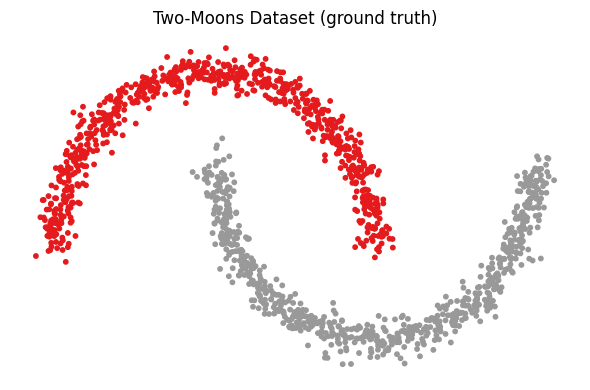

Dataset shape: (1500, 2)


In [ ]:
# ── A1: Generate Two-Moons Data ───────────────────────────────────────────────
np.random.seed(42)
n_samples = 1500

noisy_moons = sklearn.datasets.make_moons(n_samples=n_samples, noise=0.05)
X, y = noisy_moons
X = StandardScaler().fit_transform(X)

plt.figure(figsize=(6,4))
plt.scatter(X[:,0], X[:,1], c=y, cmap='Set1', s=10)
plt.title("Two-Moons Dataset (ground truth)")
plt.axis('off')
plt.tight_layout()
plt.show()
print(f"Dataset shape: {X.shape}")


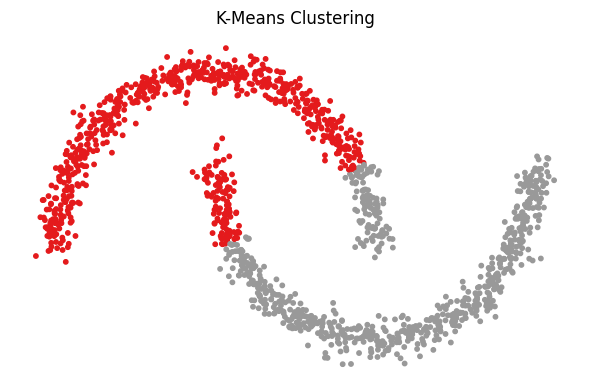

In [ ]:
# ── A1: K-Means Baseline ──────────────────────────────────────────────────────
km = KMeans(n_clusters=2, random_state=42, n_init=10)
km_labels = km.fit_predict(X)

plt.figure(figsize=(6,4))
plt.scatter(X[:,0], X[:,1], c=km_labels, cmap='Set1', s=10)
plt.title("K-Means Clustering")
plt.axis('off')
plt.tight_layout()
plt.show()


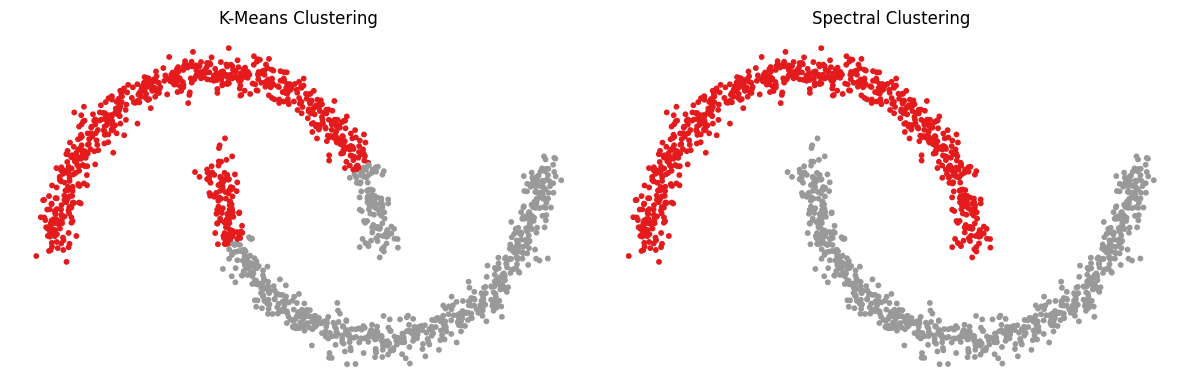

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import sklearn.datasets

# ── A1: Spectral Clustering from Scratch ─────────────────────────────────────
# TODO (3 pts): Build the RBF affinity matrix W and the unnormalised Laplacian L
#   1. Compute pairwise squared Euclidean distances between rows of X.
#   2. Choose sigma (try 0.5) and compute W = exp(-dist^2 / (2*sigma^2)).
#      Set the diagonal of W to 0.
#   3. Compute degree matrix D and L = D - W.

sigma = 0.25          # <-- you may tune this

# ---------- your code here ----------

def rbf_kernel(X, sigma):
    square_norms = np.sum(X**2, axis = 1)
    dist_sq = square_norms[:,None]+square_norms[None,:]-2*X@X.T
    K = np.exp(-(dist_sq/sigma**2))
    np.fill_diagonal(K, 0)
    return K

def degree_matrix(W):
    D = np.diag(np.sum(W, axis=1))
    return D

W = rbf_kernel(X, sigma)
D = degree_matrix(W)
L = D - W

# ------------------------------------

# TODO (3 pts): Eigen-decomposition and k-means on embedding
#   4. Compute eigenvalues/vectors of L (use np.linalg.eigh).
#   5. Pick the eigenvector corresponding to the 2nd smallest eigenvalue (Fiedler vector).
#   6. Run k-means (k=2) on the Fiedler vector reshaped to (-1,1).

# ---------- your code here ----------

_, eigenvecs = np.linalg.eigh(L)
eig = eigenvecs[:, 1].reshape(-1,1)

km = KMeans(n_clusters=2, random_state=42, n_init=10)
spec_labels = km.fit_predict(eig)

# ------------------------------------

# TODO (2 pts): Visualise
#   7. Side-by-side: K-Means result  vs  Spectral Clustering result.

# ---------- your code here ----------

plt.figure(figsize=(12,4))

plt.subplot(1, 2, 1)
plt.scatter(X[:,0], X[:,1], c=km_labels, cmap='Set1', s=10)
plt.title("K-Means Clustering")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.scatter(X[:,0], X[:,1], c=spec_labels, cmap='Set1', s=10)
plt.title("Spectral Clustering")
plt.axis('off')

plt.tight_layout()
plt.show()


---
### A2 – Karate Club Social Network (10 points)

**Task description:**  
Apply spectral clustering to the **Zachary Karate Club** graph — a classic social network benchmark — and compare the clustering with the known ground-truth community split.

| Sub-task | Points |
|----------|--------|
| Load graph & visualise with NetworkX | 2 |
| Build adjacency, degree, and Laplacian matrices | 2 |
| Spectral clustering (k=2) using Fiedler vector | 3 |
| Compare with ground-truth; report accuracy | 3 |

**Key insight:** For a graph, **W = A** (the adjacency matrix). The Fiedler vector partitions the graph into two communities that approximately minimise the *graph cut*.


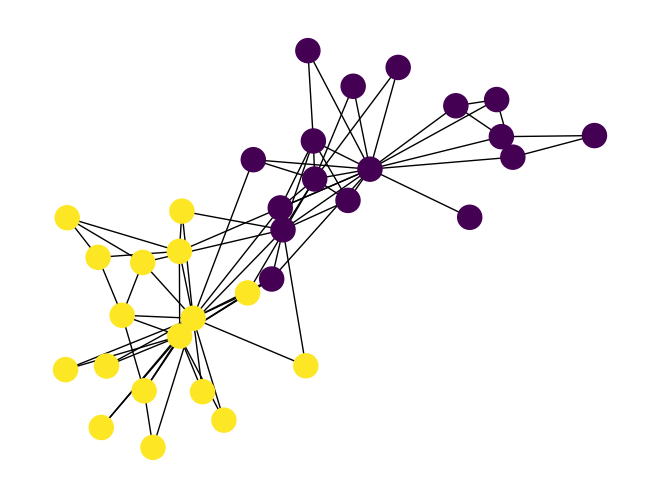

Accuracy: 0.97


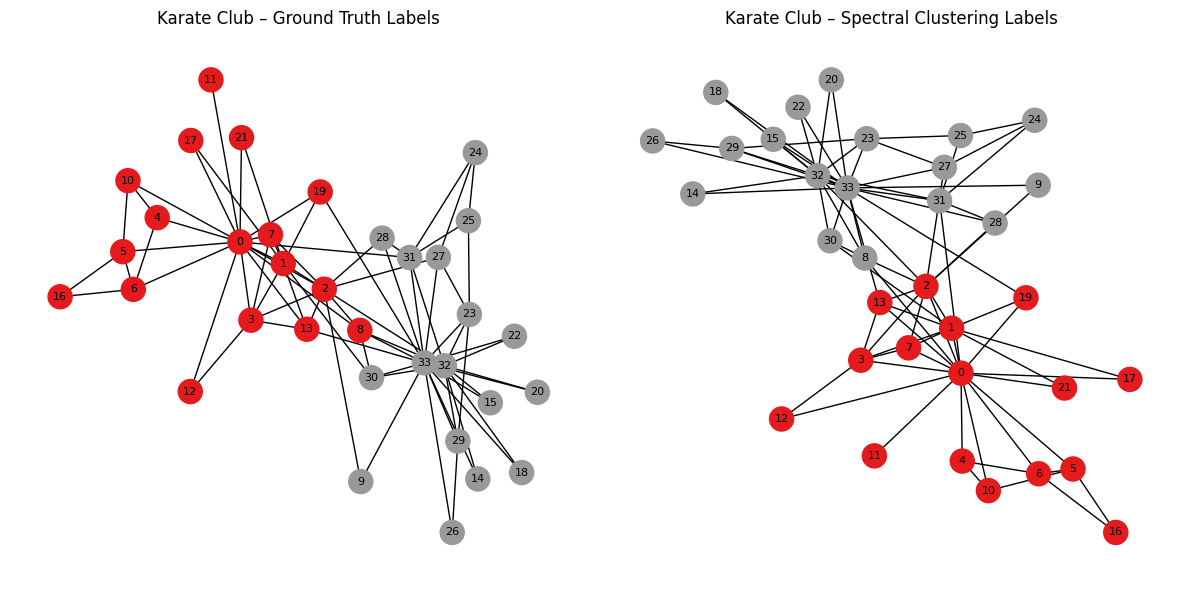

In [ ]:
# ── A2: Karate Club – Data Loading & Visualisation ───────────────────────────
G_karate = nx.karate_club_graph()

# Ground-truth labels (0 = Mr. Hi's faction, 1 = Officer's faction)
gt_labels = np.array([G_karate.nodes[n]['club'] == 'Officer' for n in G_karate.nodes()], dtype=int)

# TODO (2 pts): Draw the graph using nx.draw_spring, colouring nodes by gt_labels
# ---------- your code here ----------
nx.draw_spring(G_karate, node_color=gt_labels)
plt.show()

# ── Spectral Clustering ───────────────────────────────────────────────────────
# TODO (2 pts): Build adjacency matrix A, degree matrix D_k, Laplacian L_k = D_k - A
# Use nx.to_numpy_array(G_karate) for the adjacency matrix.
# ---------- your code here ----------


def degree_matrix(W):
    D = np.diag(np.sum(W, axis=1))
    return D

A_k  = nx.to_numpy_array(G_karate)
D_k = degree_matrix(A_k)
L_k  = D_k-A_k

# TODO (3 pts): Compute Fiedler vector and k-means to get cluster labels (k=2)
# ---------- your code here ----------

_, eigenvecs = np.linalg.eigh(L_k)
eig = eigenvecs[:, 1].reshape(-1,1)

km = KMeans(n_clusters=2, random_state=42, n_init=10)
spec_labels_k = km.fit_predict(eig)

# TODO (3 pts): Compare with ground truth
#   - Resolve label permutation ambiguity (try both 0/1 and 1/0 assignments)
#   - Report accuracy
#   - Draw the graph again coloured by spectral labels vs ground truth (side by side)
# ---------- your code here ----------

accuracy = (spec_labels_k == gt_labels).mean()
if accuracy < 0.5:
    spec_labels_k = 1 - spec_labels_k # Flip labels
    accuracy = (spec_labels_k == gt_labels).mean()

print(f"Accuracy: {accuracy:.2f}")

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
nx.draw_spring(G_karate, node_color=gt_labels, with_labels=True, cmap='Set1', node_size=300, font_size=8)
plt.title("Karate Club – Ground Truth Labels")

plt.subplot(1, 2, 2)
nx.draw_spring(G_karate, node_color=spec_labels_k, with_labels=True, cmap='Set1', node_size=300, font_size=8)
plt.title("Karate Club – Spectral Clustering Labels")
plt.tight_layout()
plt.show()


---
## Part B – Graph Neural Networks for Node Classification (30 points)

### Background

In **node classification**, we observe a graph where only a small fraction of nodes carry labels, and we want to predict labels for all remaining nodes (*transductive learning*).

**GCN Layer (Kipf & Welling, 2017):**
$$
\mathbf{x}_v^{(\ell+1)} = \mathbf{W}^{(\ell+1)}
\sum_{w \in \mathcal{N}(v) \cup \{v\}} \frac{1}{c_{w,v}}\, \mathbf{x}_w^{(\ell)}
$$

where $c_{w,v} = \sqrt{\deg(v)\cdot\deg(w)}$ is a normalisation factor.

Compared to a plain linear layer $\mathbf{x}_v^{(\ell+1)} = \mathbf{W}\mathbf{x}_v^{(\ell)}$, the GCN layer **aggregates information from neighbours**, enabling the model to leverage graph structure.


In [ ]:
from torch_geometric.datasets import KarateClub, Planetoid
from torch_geometric.transforms import NormalizeFeatures
from torch_geometric.nn import GCNConv, SAGEConv
from torch_geometric.utils import to_networkx
from sklearn.manifold import TSNE
import torch.nn as nn

def visualize_embeddings(h, color, title=""):
    z = TSNE(n_components=2, random_state=42).fit_transform(h.detach().cpu().numpy())
    plt.figure(figsize=(8,6))
    plt.scatter(z[:,0], z[:,1], s=70, c=color, cmap='Set2')
    plt.title(title); plt.xticks([]); plt.yticks([])
    plt.tight_layout(); plt.show()

def visualize_graph(data, labels, title=""):
    G = to_networkx(data, to_undirected=True)
    pos = nx.spring_layout(G, seed=42)
    plt.figure(figsize=(8,6))
    nx.draw_networkx(G, pos=pos, node_color=labels, cmap='Set2',
                     node_size=200, font_size=7)
    plt.title(title); plt.axis('off')
    plt.tight_layout(); plt.show()


---
### B1 – Node Classification on Karate Club with a Simple GNN (12 points)

| Sub-task | Points |
|----------|--------|
| Load Karate Club data via PyG; inspect & visualise | 2 |
| Define a 2-layer GCN model | 4 |
| Train for 200 epochs; report final train accuracy | 3 |
| Visualise node embeddings with t-SNE | 3 |


Data(x=[34, 34], edge_index=[2, 156], y=[34], train_mask=[34])
Nodes: 34, Edges: 156
Node features: 34
Classes: 4
Training nodes: 4


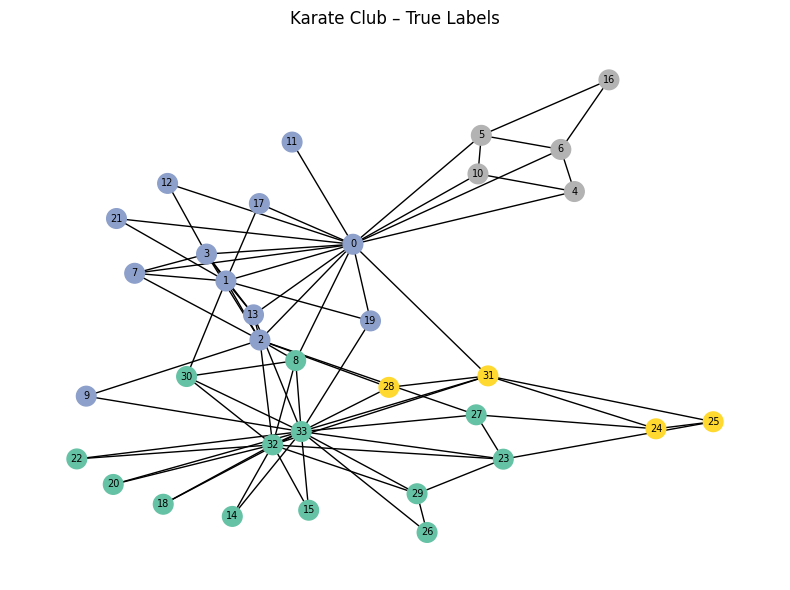

In [ ]:
# ── B1: Load Karate Club via PyG ──────────────────────────────────────────────
dataset_kc = KarateClub()
data_kc    = dataset_kc[0]

print(data_kc)
print(f"Nodes: {data_kc.num_nodes}, Edges: {data_kc.num_edges}")
print(f"Node features: {data_kc.num_node_features}")
print(f"Classes: {dataset_kc.num_classes}")
print(f"Training nodes: {data_kc.train_mask.sum().item()}")

visualize_graph(data_kc, data_kc.y.numpy(), title="Karate Club – True Labels")


In [ ]:
# ── B1: Define GCN Model ─────────────────────────────────────────────────────
# TODO (4 pts): Complete the GCN class.
#   - Use two GCNConv layers.
#   - Hidden dimension: 8
#   - Apply ReLU between layers and dropout (p=0.5) on the hidden representation.
#   - The output dimension equals the number of classes.

class GCN_KarateClub(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        # ---------- your code here ----------
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)

    def forward(self, x, edge_index):
        # ---------- your code here ----------
        x = self.conv1(x, edge_index)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        x = self.dropout(x)
        return x


model_kc = GCN_KarateClub(
    in_channels=dataset_kc.num_node_features,
    hidden_channels=8,
    out_channels=dataset_kc.num_classes
)
print(model_kc)


GCN_KarateClub(
  (conv1): GCNConv(34, 8)
  (conv2): GCNConv(8, 4)
  (relu): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
)


In [ ]:
# ── B1: Train & Evaluate ─────────────────────────────────────────────────────
# TODO (3 pts): Implement the training loop for 200 epochs.
#   Use Adam optimiser (lr=0.01, weight_decay=5e-4) and CrossEntropyLoss.
#   At every 10 epochs print the loss and training accuracy.

# ---------- your code here ----------

optimizer = torch.optim.Adam(model_kc.parameters(), lr=0.01, weight_decay=5e-4)
loss_fn = nn.CrossEntropyLoss()

for epoch in range(200):
    model_kc.train()
    optimizer.zero_grad()
    out = model_kc(data_kc.x, data_kc.edge_index)
    loss = loss_fn(out[data_kc.train_mask], data_kc.y[data_kc.train_mask])
    loss.backward()
    optimizer.step()
    if epoch % 10 == 0:
        model_kc.eval()
        out = model_kc(data_kc.x, data_kc.edge_index)
        pred = out.argmax(dim=1)
        train_acc = (pred[data_kc.train_mask] == data_kc.y[data_kc.train_mask]).float().mean()
        print(f"Epoch: {epoch:03d} | Loss: {loss} | Accuracy: {train_acc}")



Epoch: 000 | Loss: 1.3999005556106567 | Accuracy: 0.25
Epoch: 010 | Loss: 1.335463047027588 | Accuracy: 0.75
Epoch: 020 | Loss: 1.256722092628479 | Accuracy: 1.0
Epoch: 030 | Loss: 1.3434284925460815 | Accuracy: 0.75
Epoch: 040 | Loss: 1.0004795789718628 | Accuracy: 1.0
Epoch: 050 | Loss: 0.9564663171768188 | Accuracy: 1.0
Epoch: 060 | Loss: 0.8446177840232849 | Accuracy: 1.0
Epoch: 070 | Loss: 0.6961967349052429 | Accuracy: 1.0
Epoch: 080 | Loss: 0.7469788789749146 | Accuracy: 1.0
Epoch: 090 | Loss: 0.7590122818946838 | Accuracy: 1.0
Epoch: 100 | Loss: 0.5578624606132507 | Accuracy: 1.0
Epoch: 110 | Loss: 1.1087837219238281 | Accuracy: 1.0
Epoch: 120 | Loss: 1.1680001020431519 | Accuracy: 1.0
Epoch: 130 | Loss: 0.20678064227104187 | Accuracy: 1.0
Epoch: 140 | Loss: 0.4755842089653015 | Accuracy: 1.0
Epoch: 150 | Loss: 0.6309693455696106 | Accuracy: 1.0
Epoch: 160 | Loss: 0.7000551223754883 | Accuracy: 1.0
Epoch: 170 | Loss: 0.3983740210533142 | Accuracy: 1.0
Epoch: 180 | Loss: 0.71031

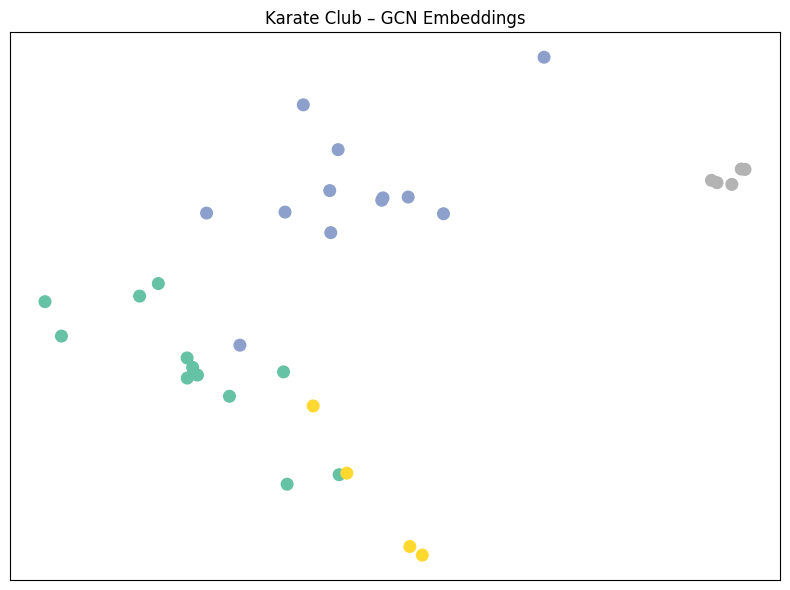

In [ ]:
# ── B1: Visualise Embeddings ─────────────────────────────────────────────────
# TODO (3 pts): After training, extract the output embeddings (model output before argmax)
#   and visualise them with the provided visualize_embeddings() function.
#   Do the clusters correspond to the true community labels?

# ---------- your code here ----------
model_kc.eval()
with torch.no_grad():
    out_embeddings = model_kc(data_kc.x, data_kc.edge_index)

visualize_embeddings(out_embeddings, data_kc.y, title="Karate Club – GCN Embeddings")


---
### B2 – Node Classification on Cora with GCN (18 points)

The **Cora** dataset is a citation network of 2 708 scientific papers across 7 categories.
Each paper is described by a 1 433-dimensional bag-of-words feature vector.
Only 140 nodes (~5%) carry labels during training (*transductive* setting).

| Sub-task | Points |
|----------|--------|
| Load Cora; print dataset statistics | 2 |
| Implement 2-layer GCN (`hidden=16`) | 4 |
| Train 200 epochs; report train & **test** accuracy | 4 |
| Visualise final embeddings with t-SNE | 2 |
| **Extension:** Replace GCNConv with SAGEConv; compare performance | 6 |


In [ ]:
# ── B2: Load Cora ─────────────────────────────────────────────────────────────
dataset_cora = Planetoid(root='data/Planetoid', name='Cora', transform=NormalizeFeatures())
data_cora    = dataset_cora[0]

print(f"Dataset: {dataset_cora}")
print(f"Nodes: {data_cora.num_nodes}  |  Edges: {data_cora.num_edges}")
print(f"Features per node: {dataset_cora.num_features}")
print(f"Classes: {dataset_cora.num_classes}")
print(f"Training nodes: {data_cora.train_mask.sum()} "
      f"({data_cora.train_mask.sum()/data_cora.num_nodes*100:.1f}%)")
print(f"Test nodes:     {data_cora.test_mask.sum()}")


Dataset: Cora()
Nodes: 2708  |  Edges: 10556
Features per node: 1433
Classes: 7
Training nodes: 140 (5.2%)
Test nodes:     1000


Processing...
Done!


In [ ]:
# ── B2: GCN Model ────────────────────────────────────────────────────────────
# TODO (4 pts): Build a 2-layer GCN for Cora.
#   - hidden_channels = 16
#   - Apply ReLU + dropout (p=0.5) between layers
#   - Output = num_classes = 7

class GCN_Cora(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        # ---------- your code here ----------
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)


    def forward(self, x, edge_index):
        # ---------- your code here ----------
        x = self.conv1(x, edge_index)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        x = self.dropout(x)
        return x


model_cora = GCN_Cora(
    in_channels=dataset_cora.num_features,
    hidden_channels=16,
    out_channels=dataset_cora.num_classes
)
print(model_cora)


GCN_Cora(
  (conv1): GCNConv(1433, 16)
  (conv2): GCNConv(16, 7)
  (relu): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
)


In [ ]:
# ── B2: Train & Evaluate GCN on Cora ─────────────────────────────────────────
# TODO (4 pts): Train for 200 epochs with Adam (lr=0.01, weight_decay=5e-4).
#   Report loss every 20 epochs.
#   After training, report BOTH train accuracy and TEST accuracy.

# ---------- your code here ----------
optimizer = torch.optim.Adam(model_cora.parameters(), lr=0.01, weight_decay=5e-4)
loss_fn = nn.CrossEntropyLoss()

for epoch in range(200):
    model_cora.train()
    optimizer.zero_grad()
    out = model_cora(data_cora.x, data_cora.edge_index)
    loss = loss_fn(out[data_cora.train_mask], data_cora.y[data_cora.train_mask])
    loss.backward()
    optimizer.step()
    if epoch % 20 == 0:
        model_cora.eval()
        out = model_cora(data_cora.x, data_cora.edge_index)
        pred = out.argmax(dim=1)
        train_acc = (pred[data_cora.train_mask] == data_cora.y[data_cora.train_mask]).float().mean()
        print(f"Epoch: {epoch:03d} | Loss: {loss:.4f} | Train Acc: {train_acc:.4f}")

model_cora.eval()
with torch.no_grad():
    out = model_cora(data_cora.x, data_cora.edge_index)
    pred = out.argmax(dim=1)
    train_acc = (pred[data_cora.train_mask] == data_cora.y[data_cora.train_mask]).float().mean()
    test_acc  = (pred[data_cora.test_mask]  == data_cora.y[data_cora.test_mask]).float().mean()

print(f"\nFinal Train Accuracy: {train_acc:.4f}")
print(f"Final Test  Accuracy: {test_acc:.4f}")

Epoch: 000 | Loss: 1.9457571506500244 | Accuracy: 0.16428571939468384
Epoch: 020 | Loss: 1.7812447547912598 | Accuracy: 0.8142856955528259
Epoch: 040 | Loss: 1.558127522468567 | Accuracy: 0.949999988079071
Epoch: 060 | Loss: 1.3641526699066162 | Accuracy: 0.9857142567634583
Epoch: 080 | Loss: 1.0882316827774048 | Accuracy: 0.9928571581840515
Epoch: 100 | Loss: 1.0367563962936401 | Accuracy: 0.9785714149475098
Epoch: 120 | Loss: 1.03834867477417 | Accuracy: 0.9857142567634583
Epoch: 140 | Loss: 1.0143744945526123 | Accuracy: 0.9928571581840515
Epoch: 160 | Loss: 1.0189632177352905 | Accuracy: 0.9928571581840515
Epoch: 180 | Loss: 1.014161229133606 | Accuracy: 0.9928571581840515

Final Train Accuracy: 0.9857
Final Test  Accuracy: 0.8000


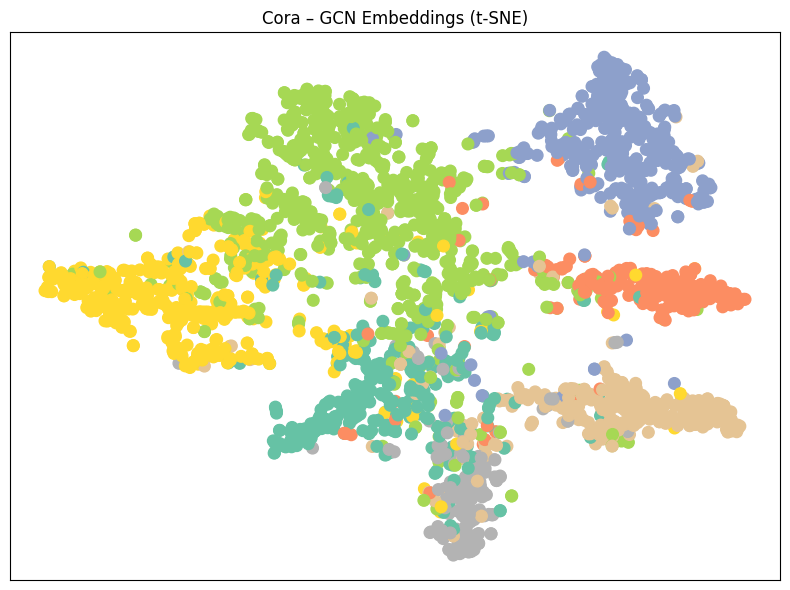

In [ ]:
# ── B2: t-SNE Visualisation ───────────────────────────────────────────────────
# TODO (2 pts): Visualise the output embeddings of the trained Cora GCN with t-SNE.

# ---------- your code here ----------

visualize_embeddings(out, data_cora.y.numpy(), title="Cora – GCN Embeddings (t-SNE)")

GraphSAGE_Cora(
  (conv1): SAGEConv(1433, 16, aggr=mean)
  (conv2): SAGEConv(16, 7, aggr=mean)
  (relu): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
)
Epoch: 000 | Loss: 1.9548 | Train Acc: 0.1429
Epoch: 020 | Loss: 1.5512 | Train Acc: 0.9857
Epoch: 040 | Loss: 1.1699 | Train Acc: 0.9929
Epoch: 060 | Loss: 0.9639 | Train Acc: 1.0000
Epoch: 080 | Loss: 0.8404 | Train Acc: 1.0000
Epoch: 100 | Loss: 0.7416 | Train Acc: 1.0000
Epoch: 120 | Loss: 0.8956 | Train Acc: 1.0000
Epoch: 140 | Loss: 0.7219 | Train Acc: 1.0000
Epoch: 160 | Loss: 0.8869 | Train Acc: 1.0000
Epoch: 180 | Loss: 0.8667 | Train Acc: 1.0000

GraphSAGE – Final Train Accuracy: 1.0000
GraphSAGE – Final Test  Accuracy: 0.8160

Comparison:
  GCN   Test Accuracy: 0.8000
  SAGE  Test Accuracy: 0.8160


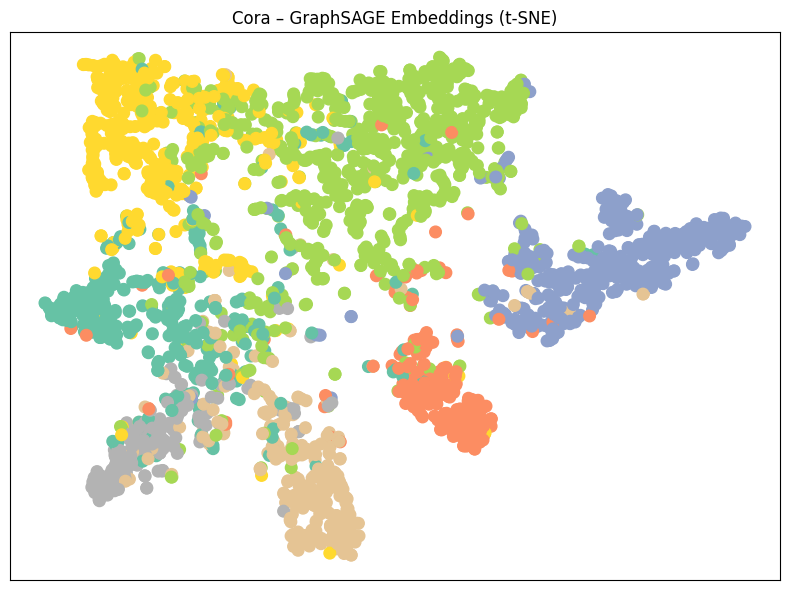

In [ ]:
# ── B2 Extension: GraphSAGE on Cora ──────────────────────────────────────────
# TODO (6 pts): Replace GCNConv with SAGEConv.
#   - Same architecture (2 layers, hidden=16, ReLU, dropout=0.5)
#   - Train identically (200 epochs, same optimiser)
#   - Compare test accuracy with GCN

# ---------- your code here ----------
class GraphSAGE_Cora(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, out_channels)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        x = self.dropout(x)
        return x


model_sage = GraphSAGE_Cora(
    in_channels=dataset_cora.num_features,
    hidden_channels=16,
    out_channels=dataset_cora.num_classes
)
print(model_sage)

optimizer_sage = torch.optim.Adam(model_sage.parameters(), lr=0.01, weight_decay=5e-4)
loss_fn = nn.CrossEntropyLoss()

for epoch in range(200):
    model_sage.train()
    optimizer_sage.zero_grad()
    out_sage = model_sage(data_cora.x, data_cora.edge_index)
    loss = loss_fn(out_sage[data_cora.train_mask], data_cora.y[data_cora.train_mask])
    loss.backward()
    optimizer_sage.step()
    if epoch % 20 == 0:
        model_sage.eval()
        out_sage = model_sage(data_cora.x, data_cora.edge_index)
        pred = out_sage.argmax(dim=1)
        train_acc = (pred[data_cora.train_mask] == data_cora.y[data_cora.train_mask]).float().mean()
        print(f"Epoch: {epoch:03d} | Loss: {loss:.4f} | Train Acc: {train_acc:.4f}")

model_sage.eval()
with torch.no_grad():
    out_sage = model_sage(data_cora.x, data_cora.edge_index)
    pred = out_sage.argmax(dim=1)
    sage_train_acc = (pred[data_cora.train_mask] == data_cora.y[data_cora.train_mask]).float().mean()
    sage_test_acc  = (pred[data_cora.test_mask]  == data_cora.y[data_cora.test_mask]).float().mean()

print(f"\nGraphSAGE – Final Train Accuracy: {sage_train_acc:.4f}")
print(f"GraphSAGE – Final Test  Accuracy: {sage_test_acc:.4f}")
print(f"\nComparison:")
print(f"  GCN   Test Accuracy: {test_acc:.4f}")
print(f"  SAGE  Test Accuracy: {sage_test_acc:.4f}")

visualize_embeddings(out_sage, data_cora.y.numpy(), title="Cora – GraphSAGE Embeddings (t-SNE)")
